# Đồ án KTDL - Baseline Super MultiDomain connectivity

Notebook này dùng để chạy baseline với các connectivity features có sẵn trong `Super_MultiDomain_Features_Role3`.

File Super hiện có:
- 5 bands: `delta`, `theta`, `alpha`, `beta`, `gamma`
- 6 connectivity metrics: `cov`, `corr`, `plv`, `coh`, `csd`, `mi`
- tổng cộng `5 x 6 = 30` feature sets

Mục tiêu chính:
- đọc feature trực tiếp từ Super folder/NPZ, không tính lại từ `.fif`
- chạy base classifier `FgMDM` cho từng `band x metric`
- đánh giá bằng LOSOCV ở mức subject
- tạo bảng baseline và heatmap ROC-AUC theo connectivity có trong file

Lưu ý: đây là baseline theo Super MultiDomain file, không phải full 60 metrics của paper.


## 1. Import thư viện

Notebook dùng lại code trích connectivity trong `src/ftd_mlflow_pipeline/connectivity.py`.


In [1]:
from pathlib import Path
import json
import os
import sys
import time
import warnings

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyriemann.classification import FgMDM
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score, roc_curve

ROOT = Path('/home/dohaidang/DataMining_Project')
sys.path.insert(0, str(ROOT / 'src'))

from ftd_mlflow_pipeline.connectivity import FeatureSet

warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')

PAPER_BANDS = ('delta', 'theta', 'alpha', 'beta', 'gamma')
PAPER_METRICS = ('cov', 'corr', 'xcov', 'xcorr', 'csd', 'coh', 'mi', 'ecc', 'aecov', 'aecorr', 'plv', 'wplv')


## 2. Cấu hình chạy

Notebook này dùng folder `Full_MultiDomain_Features_Role3`, tức là bộ feature đã có đủ **60 connectivity sets** theo paper:

- 5 dải tần: `delta`, `theta`, `alpha`, `beta`, `gamma`
- 12 connectivity metrics: `cov`, `corr`, `xcov`, `xcorr`, `csd`, `coh`, `mi`, `ecc`, `aecov`, `aecorr`, `plv`, `wplv`

Mỗi tổ hợp `band + metric` được chạy như một baseline FgMDM riêng bằng LOSOCV. Đây là baseline từng feature, không phải stacked ensemble.


In [2]:
PRECOMPUTED_DIR = ROOT / 'Full_MultiDomain_Features_Role3'
OUTPUT_DIR = ROOT / 'notebook_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_TAG = 'full_paper_60_connectivity'

RUN_MODE = 'full_paper_60'
SELECTED_BANDS = PAPER_BANDS
SELECTED_METRICS = PAPER_METRICS

FGMDM_METRIC = 'euclid'
FGMDM_FALLBACK_METRICS = ('riemann',)
RANDOM_STATE = 42

PROBLEMS = {
    'ad_hc': ('A', 'C', 'AD', 'HC'),
    'ftd_hc': ('F', 'C', 'FTD', 'HC'),
    'ftd_ad': ('F', 'A', 'FTD', 'AD'),
}

print('RUN_MODE:', RUN_MODE)
print('Feature folder:', PRECOMPUTED_DIR)
print('Bands:', SELECTED_BANDS)
print('Metrics:', SELECTED_METRICS)
print('Total feature sets:', len(SELECTED_BANDS) * len(SELECTED_METRICS))


RUN_MODE: full_paper_60
Feature folder: /home/dohaidang/DataMining_Project/Full_MultiDomain_Features_Role3
Bands: ('delta', 'theta', 'alpha', 'beta', 'gamma')
Metrics: ('cov', 'corr', 'xcov', 'xcorr', 'csd', 'coh', 'mi', 'ecc', 'aecov', 'aecorr', 'plv', 'wplv')
Total feature sets: 60


## 3. Ý nghĩa các metrics trong Super file

Super file hiện có 6 connectivity metrics. Các metric như `xcov`, `xcorr`, `ecc`, `aecov`, `aecorr`, `wplv` không có trong file này nên notebook không chạy các metric đó.


In [3]:
metric_descriptions = pd.DataFrame([
    ('cov', 'Covariance', 'Quan hệ tuyến tính theo biên độ tín hiệu.'),
    ('corr', 'Correlation', 'Covariance được chuẩn hóa theo phương sai.'),
    ('plv', 'Phase locking value', 'Đồng bộ pha giữa các kênh.'),
    ('coh', 'Coherence', 'Mức đồng bộ phổ giữa hai kênh.'),
    ('csd', 'Cross-spectral density', 'Liên hệ giữa hai kênh trong miền tần số.'),
    ('mi', 'Mutual information', 'Quan hệ phi tuyến dựa trên thông tin chung.'),
], columns=['metric', 'name', 'meaning'])
metric_descriptions


,metric,name,meaning
0,cov,Covariance,Quan hệ tuyến tính theo biên độ tín hiệu.
1,corr,Correlation,Covariance được chuẩn hóa theo phương sai.
2,plv,Phase locking value,Đồng bộ pha giữa các kênh.
3,coh,Coherence,Mức đồng bộ phổ giữa hai kênh.
4,csd,Cross-spectral density,Liên hệ giữa hai kênh trong miền tần số.
5,mi,Mutual information,Quan hệ phi tuyến dựa trên thông tin chung.


## 4. Đọc feature catalog từ Super MultiDomain

Cell này đọc các file `.npy` có trong `Super_MultiDomain_Features_Role3` và đóng gói thành `FeatureSet` để dùng lại các hàm LOSOCV bên dưới.


In [4]:
def normalize_subject_ids(subject_ids: np.ndarray) -> np.ndarray:
    normalized = []
    for subject_id in subject_ids.astype(str):
        if subject_id.startswith('sub-'):
            normalized.append(subject_id)
        else:
            normalized.append(f'sub-{subject_id.zfill(3)}')
    return np.asarray(normalized)


def discover_paper_feature_names(precomputed_dir: Path, bands: tuple[str, ...], metrics: tuple[str, ...]) -> list[str]:
    expected_names = [f'{band}_{metric}' for band in bands for metric in metrics]
    missing = [name for name in expected_names if not (precomputed_dir / f'{name}.npy').exists()]
    if missing:
        raise FileNotFoundError(
            'Thieu feature file trong Full_MultiDomain_Features_Role3: ' + ', '.join(missing)
        )
    return expected_names


def load_paper_feature_catalog(precomputed_dir: Path, bands: tuple[str, ...], metrics: tuple[str, ...]):
    labels = np.load(precomputed_dir / 'labels.npy', allow_pickle=True).astype(str)
    subject_ids = normalize_subject_ids(np.load(precomputed_dir / 'subject_ids.npy', allow_pickle=True))
    feature_names = discover_paper_feature_names(precomputed_dir, bands, metrics)

    catalog = {}
    rows = []
    for feature_name in feature_names:
        band, metric = feature_name.split('_', maxsplit=1)
        start = time.time()
        matrices = np.load(precomputed_dir / f'{feature_name}.npy', allow_pickle=True).astype(np.float64)
        feature_set = FeatureSet(
            band=band,
            metric=metric,
            matrices=matrices,
            group_codes=labels,
            subject_ids=subject_ids,
        )
        catalog[f'{band}__{metric}'] = feature_set
        rows.append({
            'feature': f'{band}__{metric}',
            'band': band,
            'metric': metric,
            'n_epochs': matrices.shape[0],
            'n_channels': matrices.shape[1],
            'seconds': time.time() - start,
        })
        print(f'{band}__{metric}: {matrices.shape}')
    return catalog, pd.DataFrame(rows)


feature_catalog, feature_load_log = load_paper_feature_catalog(
    PRECOMPUTED_DIR,
    SELECTED_BANDS,
    SELECTED_METRICS,
)
print('Loaded feature sets:', len(feature_catalog))
feature_load_log


delta__cov: (13422, 19, 19)
delta__corr: (13422, 19, 19)
delta__xcov: (13422, 19, 19)
delta__xcorr: (13422, 19, 19)
delta__csd: (13422, 19, 19)
delta__coh: (13422, 19, 19)
delta__mi: (13422, 19, 19)
delta__ecc: (13422, 19, 19)
delta__aecov: (13422, 19, 19)
delta__aecorr: (13422, 19, 19)
delta__plv: (13422, 19, 19)
delta__wplv: (13422, 19, 19)
theta__cov: (13422, 19, 19)
theta__corr: (13422, 19, 19)
theta__xcov: (13422, 19, 19)
theta__xcorr: (13422, 19, 19)
theta__csd: (13422, 19, 19)
theta__coh: (13422, 19, 19)
theta__mi: (13422, 19, 19)
theta__ecc: (13422, 19, 19)
theta__aecov: (13422, 19, 19)
theta__aecorr: (13422, 19, 19)
theta__plv: (13422, 19, 19)
theta__wplv: (13422, 19, 19)
alpha__cov: (13422, 19, 19)
alpha__corr: (13422, 19, 19)
alpha__xcov: (13422, 19, 19)
alpha__xcorr: (13422, 19, 19)
alpha__csd: (13422, 19, 19)
alpha__coh: (13422, 19, 19)
alpha__mi: (13422, 19, 19)
alpha__ecc: (13422, 19, 19)
alpha__aecov: (13422, 19, 19)
alpha__aecorr: (13422, 19, 19)
alpha__plv: (13422, 19

,feature,band,metric,n_epochs,n_channels,seconds
0,delta__cov,delta,cov,13422,19,0.048570
1,delta__corr,delta,corr,13422,19,0.083940
2,delta__xcov,delta,xcov,13422,19,0.096710
3,delta__xcorr,delta,xcorr,13422,19,0.071134
4,delta__csd,delta,csd,13422,19,0.069941
5,delta__coh,delta,coh,13422,19,0.068991
6,delta__mi,delta,mi,13422,19,0.079366
7,delta__ecc,delta,ecc,13422,19,0.062112
8,delta__aecov,delta,aecov,13422,19,0.077137
9,delta__aecorr,delta,aecorr,13422,19,0.070002


## 5. Hàm hỗ trợ LOSOCV baseline

Baseline này chạy từng feature riêng lẻ:

`1 band + 1 metric -> FgMDM -> subject-level LOSOCV -> ROC-AUC`

Đây là cách mô phỏng tinh thần Fig. 2 trong paper.


In [5]:
def binary_subset(feature_set: FeatureSet, positive_code: str, negative_code: str):
    mask = np.isin(feature_set.group_codes, [positive_code, negative_code])
    X = feature_set.matrices[mask]
    y = (feature_set.group_codes[mask] == positive_code).astype(int)
    subjects = feature_set.subject_ids[mask]
    return X, y, subjects


def build_subject_frame(labels: np.ndarray, subject_ids: np.ndarray) -> pd.DataFrame:
    frame = pd.DataFrame({'subject_id': subject_ids, 'label': labels})
    subject_frame = frame.drop_duplicates('subject_id').sort_values('subject_id').reset_index(drop=True)
    counts = frame.groupby('subject_id').size().rename('epoch_count')
    subject_frame = subject_frame.merge(counts, on='subject_id', how='left')
    subject_frame['sample_weight'] = 1.0 / subject_frame['epoch_count']
    return subject_frame


def epoch_weights(subject_ids: np.ndarray) -> np.ndarray:
    counts = pd.Series(subject_ids).value_counts()
    return np.asarray([1.0 / counts[sid] for sid in subject_ids], dtype=np.float64)


def aggregate_probs_by_subject(probabilities: np.ndarray, subject_ids: np.ndarray) -> pd.Series:
    frame = pd.DataFrame({'subject_id': subject_ids, 'probability': probabilities})
    return frame.groupby('subject_id')['probability'].mean()


def predict_positive_proba(model, X: np.ndarray, positive_label: int = 1) -> np.ndarray:
    class_index = int(np.where(model.classes_ == positive_label)[0][0])
    return model.predict_proba(X)[:, class_index]


def fit_fgmdm_with_fallback(X_train: np.ndarray, y_train: np.ndarray, sample_weight: np.ndarray):
    last_error = None
    for metric in (FGMDM_METRIC, *FGMDM_FALLBACK_METRICS):
        try:
            model = FgMDM(metric=metric)
            model.fit(X_train, y_train, sample_weight=sample_weight)
            return model, metric
        except ValueError as exc:
            last_error = exc
    raise last_error


def evaluate_subject_predictions(y_true: np.ndarray, y_prob: np.ndarray):
    y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'sensitivity': float(tp / (tp + fn) if (tp + fn) else 0.0),
        'specificity': float(tn / (tn + fp) if (tn + fp) else 0.0),
    }


## 6. Chạy LOSOCV cho một feature

Hàm này giữ lại từng subject làm test, train `FgMDM` trên các subject còn lại, sau đó average xác suất epoch lên subject-level.


In [6]:
def run_base_feature_losocv(feature_name: str, feature_set: FeatureSet, problem_name: str):
    positive_code, negative_code, positive_name, negative_name = PROBLEMS[problem_name]
    X, y, subjects = binary_subset(feature_set, positive_code, negative_code)
    subject_table = build_subject_frame(y, subjects)

    predictions = []
    fold_metrics = []
    for _, test_row in subject_table.iterrows():
        test_subject_id = str(test_row['subject_id'])
        train_subject_ids = set(subject_table.loc[subject_table['subject_id'] != test_subject_id, 'subject_id'])
        train_mask = np.isin(subjects, list(train_subject_ids))
        test_mask = subjects == test_subject_id

        X_train, y_train, s_train = X[train_mask], y[train_mask], subjects[train_mask]
        X_test, s_test = X[test_mask], subjects[test_mask]

        model, used_metric = fit_fgmdm_with_fallback(X_train, y_train, epoch_weights(s_train))
        epoch_prob = predict_positive_proba(model, X_test)
        subject_prob = aggregate_probs_by_subject(epoch_prob, s_test).loc[test_subject_id]
        predictions.append({
            'problem': problem_name,
            'feature': feature_name,
            'band': feature_set.band,
            'metric': feature_set.metric,
            'subject_id': test_subject_id,
            'y_true': int(test_row['label']),
            'y_prob': float(subject_prob),
            'fgmdm_metric_used': used_metric,
        })

    predictions_df = pd.DataFrame(predictions)
    metrics = evaluate_subject_predictions(
        predictions_df['y_true'].to_numpy(),
        predictions_df['y_prob'].to_numpy(),
    )
    metrics.update({
        'problem': problem_name,
        'feature': feature_name,
        'band': feature_set.band,
        'metric': feature_set.metric,
        'n_subjects': int(len(subject_table)),
    })
    return metrics, predictions_df


## 7. Chạy baseline cho toàn bộ feature được chọn

Full mode sẽ chạy `3 problems x 60 feature sets`. Nếu đang chạy full, nên để máy chạy lâu và không restart kernel.


In [7]:
BASELINE_RESULTS_PATH = OUTPUT_DIR / f'{OUTPUT_TAG}_baseline_metrics.csv'
BASELINE_PREDICTIONS_PATH = OUTPUT_DIR / f'{OUTPUT_TAG}_baseline_predictions.csv'
USE_CACHED_BASELINE = True  # True: dung lai ket qua full_paper_60_connectivity neu da chay xong.

if USE_CACHED_BASELINE and BASELINE_RESULTS_PATH.exists() and BASELINE_PREDICTIONS_PATH.exists():
    baseline_results_df = pd.read_csv(BASELINE_RESULTS_PATH)
    baseline_predictions_df = pd.read_csv(BASELINE_PREDICTIONS_PATH)
    print('Loaded cached baseline results')
else:
    result_rows = []
    prediction_frames = []
    total = len(PROBLEMS) * len(feature_catalog)
    counter = 0
    for problem_name in PROBLEMS:
        for feature_name, feature_set in feature_catalog.items():
            counter += 1
            start = time.time()
            metrics, predictions = run_base_feature_losocv(feature_name, feature_set, problem_name)
            metrics['seconds'] = time.time() - start
            result_rows.append(metrics)
            prediction_frames.append(predictions)
            print(
                f'[{counter}/{total}] {problem_name} | {feature_name} | '
                f"AUC={metrics['roc_auc']:.4f} | {metrics['seconds']:.1f}s"
            )
    baseline_results_df = pd.DataFrame(result_rows)
    baseline_predictions_df = pd.concat(prediction_frames, ignore_index=True)
    baseline_results_df.to_csv(BASELINE_RESULTS_PATH, index=False)
    baseline_predictions_df.to_csv(BASELINE_PREDICTIONS_PATH, index=False)

baseline_results_df.sort_values(['problem', 'roc_auc'], ascending=[True, False]).head(20)


[1/180] ad_hc | delta__cov | AUC=0.5000 | 23.5s
[2/180] ad_hc | delta__corr | AUC=0.8132 | 22.1s
[3/180] ad_hc | delta__xcov | AUC=0.5000 | 21.9s
[4/180] ad_hc | delta__xcorr | AUC=0.8214 | 22.2s
[5/180] ad_hc | delta__csd | AUC=0.5000 | 22.0s
[6/180] ad_hc | delta__coh | AUC=0.8113 | 21.8s
[7/180] ad_hc | delta__mi | AUC=0.7960 | 22.0s
[8/180] ad_hc | delta__ecc | AUC=0.8113 | 21.7s
[9/180] ad_hc | delta__aecov | AUC=0.5000 | 21.5s
[10/180] ad_hc | delta__aecorr | AUC=0.8142 | 22.1s
[11/180] ad_hc | delta__plv | AUC=0.7969 | 22.1s
[12/180] ad_hc | delta__wplv | AUC=0.8056 | 21.6s
[13/180] ad_hc | theta__cov | AUC=0.5000 | 21.8s
[14/180] ad_hc | theta__corr | AUC=0.8266 | 21.7s
[15/180] ad_hc | theta__xcov | AUC=0.5000 | 22.1s
[16/180] ad_hc | theta__xcorr | AUC=0.8362 | 21.8s
[17/180] ad_hc | theta__csd | AUC=0.5000 | 21.7s
[18/180] ad_hc | theta__coh | AUC=0.7931 | 22.5s
[19/180] ad_hc | theta__mi | AUC=0.8180 | 22.3s
[20/180] ad_hc | theta__ecc | AUC=0.8525 | 23.3s
[21/180] ad_hc | 

,roc_auc,accuracy,f1,sensitivity,specificity,problem,feature,band,metric,n_subjects,seconds
34,0.855364,0.815385,0.823529,0.777778,0.862069,ad_hc,alpha__plv,alpha,plv,65,21.381948
19,0.852490,0.784615,0.787879,0.722222,0.862069,ad_hc,theta__ecc,theta,ecc,65,23.265424
25,0.846743,0.815385,0.828571,0.805556,0.827586,ad_hc,alpha__corr,alpha,corr,65,22.121949
33,0.845785,0.846154,0.857143,0.833333,0.862069,ad_hc,alpha__aecorr,alpha,aecorr,65,22.008897
30,0.841954,0.800000,0.816901,0.805556,0.793103,ad_hc,alpha__mi,alpha,mi,65,21.952443
35,0.840038,0.815385,0.823529,0.777778,0.862069,ad_hc,alpha__wplv,alpha,wplv,65,21.250883
37,0.837165,0.723077,0.742857,0.722222,0.724138,ad_hc,beta__corr,beta,corr,65,22.437865
15,0.836207,0.784615,0.787879,0.722222,0.862069,ad_hc,theta__xcorr,theta,xcorr,65,21.810092
29,0.834291,0.815385,0.828571,0.805556,0.827586,ad_hc,alpha__coh,alpha,coh,65,21.322462
31,0.834291,0.815385,0.833333,0.833333,0.793103,ad_hc,alpha__ecc,alpha,ecc,65,21.869619


## 8. Best feature baseline theo từng bài toán

Bảng này cho biết feature đơn lẻ nào tốt nhất cho từng bài toán.


In [8]:
best_baseline_by_problem = (
    baseline_results_df
    .sort_values(['problem', 'roc_auc'], ascending=[True, False])
    .groupby('problem')
    .head(5)
    .reset_index(drop=True)
)
best_baseline_by_problem


,roc_auc,accuracy,f1,sensitivity,specificity,problem,feature,band,metric,n_subjects,seconds
0,0.855364,0.815385,0.823529,0.777778,0.862069,ad_hc,alpha__plv,alpha,plv,65,21.381948
1,0.852490,0.784615,0.787879,0.722222,0.862069,ad_hc,theta__ecc,theta,ecc,65,23.265424
2,0.846743,0.815385,0.828571,0.805556,0.827586,ad_hc,alpha__corr,alpha,corr,65,22.121949
3,0.845785,0.846154,0.857143,0.833333,0.862069,ad_hc,alpha__aecorr,alpha,aecorr,65,22.008897
4,0.841954,0.800000,0.816901,0.805556,0.793103,ad_hc,alpha__mi,alpha,mi,65,21.952443
5,0.733092,0.644068,0.553191,0.565217,0.694444,ftd_ad,delta__corr,delta,corr,59,18.911989
6,0.721014,0.677966,0.641509,0.739130,0.638889,ftd_ad,delta__ecc,delta,ecc,59,18.430421
7,0.683575,0.677966,0.595745,0.608696,0.722222,ftd_ad,delta__coh,delta,coh,59,19.471587
8,0.683575,0.661017,0.583333,0.608696,0.694444,ftd_ad,delta__wplv,delta,wplv,59,19.166823
9,0.677536,0.610169,0.530612,0.565217,0.638889,ftd_ad,delta__aecorr,delta,aecorr,59,19.613298


## 9. Heatmap ROC-AUC mô phỏng Fig. 2

Paper dùng heatmap để trình bày ROC-AUC theo từng `band x metric`. Cell này vẽ lại theo kết quả baseline của project.


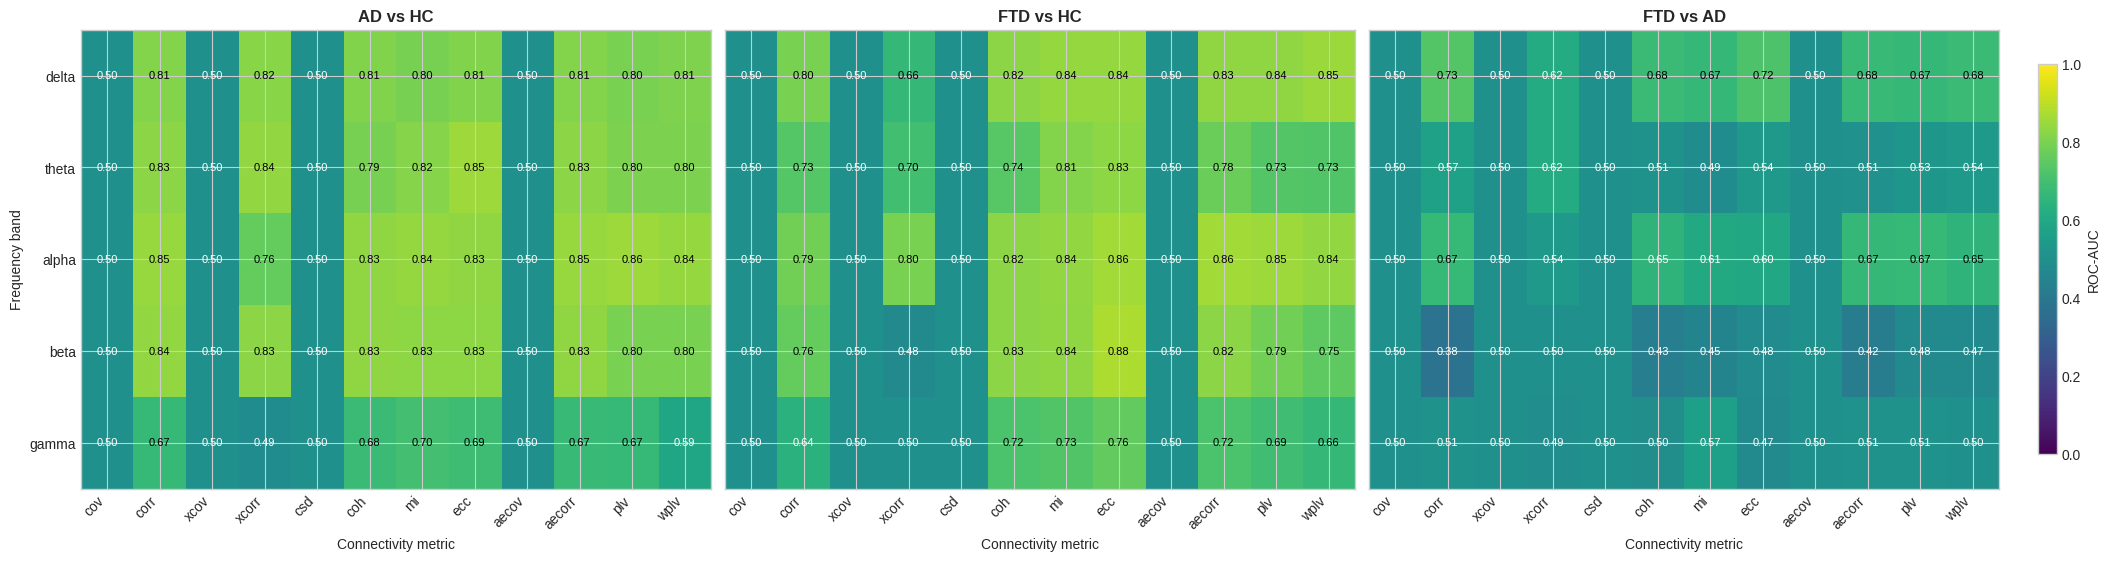

In [12]:
problem_labels = {
    'ad_hc': 'AD vs HC',
    'ftd_hc': 'FTD vs HC',
    'ftd_ad': 'FTD vs AD',
}

fig, axes = plt.subplots(
    1,
    len(PROBLEMS),
    figsize=(21, 5.5),
    sharey=True,
    constrained_layout=True,
)

for ax, problem_name in zip(axes, PROBLEMS):
    problem_df = baseline_results_df[baseline_results_df['problem'] == problem_name]
    heatmap_data = (
        problem_df
        .pivot(index='band', columns='metric', values='roc_auc')
        .reindex(index=PAPER_BANDS)
        .reindex(columns=SELECTED_METRICS)
    )

    im = ax.imshow(
        heatmap_data.to_numpy(),
        vmin=0,
        vmax=1,
        cmap='viridis',
        aspect='auto',
    )

    ax.set_title(problem_labels[problem_name], fontsize=12, fontweight='bold')
    ax.set_xlabel('Connectivity metric')
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)

    for i in range(heatmap_data.shape[0]):
        for j in range(heatmap_data.shape[1]):
            value = heatmap_data.iloc[i, j]
            if pd.notna(value):
                text_color = 'white' if value < 0.65 else 'black'
                ax.text(
                    j,
                    i,
                    f'{value:.2f}',
                    ha='center',
                    va='center',
                    fontsize=8,
                    color=text_color,
                )

axes[0].set_ylabel('Frequency band')

colorbar = fig.colorbar(
    im,
    ax=axes,
    location='right',
    shrink=0.85,
    pad=0.02,
)
colorbar.set_label('ROC-AUC', rotation=90)

plt.show()

## 10. So sánh best baseline với stacked result hiện tại

Cell này so sánh best single-feature baseline với kết quả stacked LOSOCV đã chạy trong notebook chính nếu file summary có sẵn.


In [10]:
stacked_summary_path = OUTPUT_DIR / 'all_binary_losocv_metrics_summary.csv'
if stacked_summary_path.exists():
    stacked_summary = pd.read_csv(stacked_summary_path, index_col=0).drop(index='mean', errors='ignore')
    best_single = baseline_results_df.sort_values('roc_auc', ascending=False).groupby('problem').first()
    comparison = pd.DataFrame({
        'best_single_feature_auc': best_single['roc_auc'],
        'best_single_feature': best_single['feature'],
        'stacked_auc': stacked_summary['roc_auc'],
    })
    comparison['stacked_minus_best_single'] = comparison['stacked_auc'] - comparison['best_single_feature_auc']
    display(comparison)
else:
    print('Chua co all_binary_losocv_metrics_summary.csv de so sanh voi stacked model.')


,best_single_feature_auc,best_single_feature,stacked_auc,stacked_minus_best_single
problem,,,,
ad_hc,0.855364,alpha__plv,0.827586,-0.027778
ftd_ad,0.733092,delta__corr,0.590580,-0.142512
ftd_hc,0.878561,beta__ecc,0.847076,-0.031484


## 11. Lưu bảng tổng hợp cuối

Các file output chính:
- baseline metrics theo từng feature
- subject prediction theo từng feature
- best feature theo từng problem


In [11]:
BEST_BASELINE_PATH = OUTPUT_DIR / f'{OUTPUT_TAG}_baseline_best_by_problem.csv'
best_baseline_by_problem.to_csv(BEST_BASELINE_PATH, index=False)

print('Da luu:')
print(' -', BASELINE_RESULTS_PATH)
print(' -', BASELINE_PREDICTIONS_PATH)
print(' -', BEST_BASELINE_PATH)


Da luu:
 - /home/dohaidang/DataMining_Project/notebook_outputs/full_paper_60_connectivity_baseline_metrics.csv
 - /home/dohaidang/DataMining_Project/notebook_outputs/full_paper_60_connectivity_baseline_predictions.csv
 - /home/dohaidang/DataMining_Project/notebook_outputs/full_paper_60_connectivity_baseline_best_by_problem.csv


## 12. Cách dùng notebook này trong báo cáo

Notebook này là baseline theo `Super_MultiDomain_Features_Role3`, gồm 30 connectivity features có sẵn.

Có thể viết:

`We evaluated a Super MultiDomain single-feature baseline using 30 precomputed connectivity features across five frequency bands and six connectivity metrics. Each band-metric pair was evaluated independently with FgMDM under subject-level LOSOCV, and the resulting ROC-AUC values were visualized as a heatmap.`

Không nên gọi đây là full 60-feature paper replication, vì Super file không chứa đủ 12 metrics của paper.
